In [1]:
import os
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['VECLIB_MAXIMUM_THREADS'] = '1'
os.environ['NUMEXPR_NUM_THREADS'] = '1'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['NPROC'] = '1'
os.environ['JAX_ENABLE_X64'] = 'True'
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
# os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '.XX'
# os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'platform'

import corner
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
from MultiHMCGibbs import MultiHMCGibbs

## data

In [2]:
n = 100
mu = 0
sigma = 1

In [3]:
x = jax.random.normal(jax.random.key(0), n) * sigma + mu
obs = jax.random.normal(jax.random.key(1), n) * 1 + x

W0301 13:17:22.617766 3245778 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0301 13:17:22.620877 3245189 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.


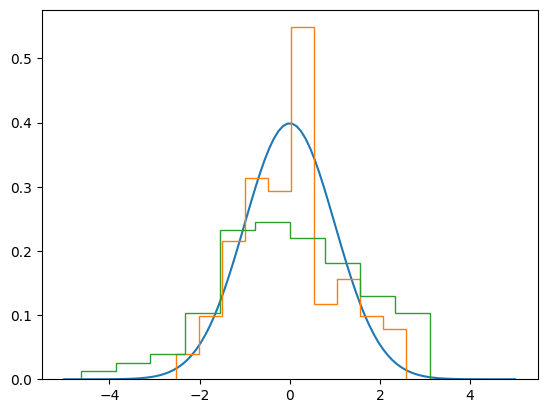

In [4]:
xx = np.linspace(-5, 5, 100)
pp = jax.scipy.stats.norm.pdf(xx, mu, sigma)
plt.plot(xx, pp)
plt.hist(x, density = True, histtype = 'step')
plt.hist(obs, density = True, histtype = 'step');

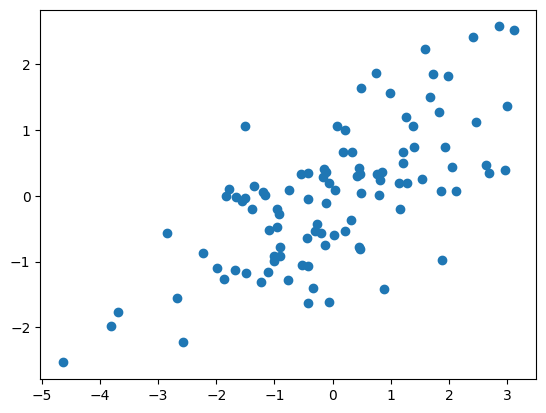

In [5]:
plt.scatter(obs, x)

In [6]:
def log_likelihood(obs, x):
    return jax.scipy.stats.norm.logpdf(obs, x, 1)

## naive

In [7]:
def model():
    mu = numpyro.sample('mu', numpyro.distributions.Normal())
    sigma = numpyro.sample('sigma', numpyro.distributions.LogNormal())

    with numpyro.plate('n', obs.size):
        x = numpyro.sample('x', numpyro.distributions.Normal(mu, sigma))

    ll = jax.vmap(log_likelihood)(obs, x)
    numpyro.factor('factor', ll.sum())

In [8]:
nuts = numpyro.infer.NUTS(model)
mcmc = numpyro.infer.MCMC(nuts, num_warmup = 1_000, num_samples = 1_000)
mcmc.run(jax.random.key(2))

sample: 100%|███████| 2000/2000 [00:10<00:00, 195.93it/s, 15 steps of size 3.60e-01. acc. prob=0.88]


In [9]:
mcmc.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
        mu      0.02      0.15      0.02     -0.23      0.27   1461.41      1.00
     sigma      1.19      0.15      1.19      0.94      1.44    514.66      1.00
      x[0]     -0.82      0.75     -0.82     -2.02      0.41   2130.54      1.00
      x[1]     -0.49      0.77     -0.49     -1.79      0.70   2011.56      1.00
      x[2]      1.15      0.79      1.14     -0.12      2.49   2651.17      1.00
      x[3]      0.68      0.74      0.67     -0.57      1.82   1666.26      1.00
      x[4]     -0.44      0.73     -0.47     -1.63      0.78   2431.82      1.00
      x[5]      0.22      0.77      0.23     -0.96      1.55   2143.94      1.00
      x[6]      0.76      0.72      0.78     -0.41      1.86   2494.37      1.00
      x[7]     -0.23      0.73     -0.24     -1.47      0.88   2073.74      1.00
      x[8]      0.02      0.75      0.06     -1.20      1.25   2458.71      1.00
      x[9]     -1.29      0

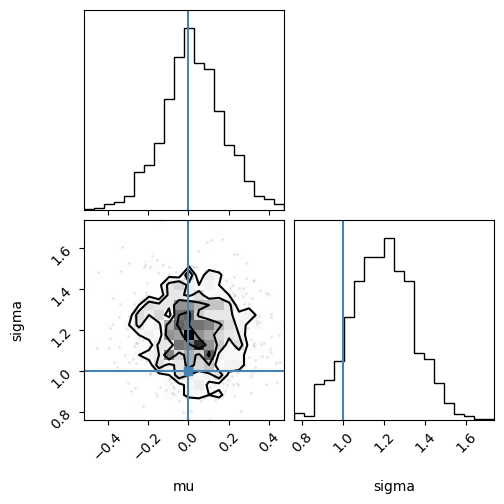

In [10]:
corner.corner(
    np.transpose([mcmc.get_samples()['mu'], mcmc.get_samples()['sigma']]),
    labels = ('mu', 'sigma'),
    truths = (0, 1),
);

## reparam

In [11]:
def model():
    mu = numpyro.sample('mu', numpyro.distributions.Normal())
    sigma = numpyro.sample('sigma', numpyro.distributions.LogNormal())

    with numpyro.plate('n', obs.size):
        x = numpyro.sample('_x', numpyro.distributions.Normal())
        x = numpyro.deterministic('x', x * sigma + mu)

    ll = jax.vmap(log_likelihood)(obs, x)
    numpyro.factor('factor', ll.sum())

In [12]:
nuts = numpyro.infer.NUTS(model)
mcmc = numpyro.infer.MCMC(nuts, num_warmup = 1_000, num_samples = 1_000)
mcmc.run(jax.random.key(2))

sample: 100%|███████| 2000/2000 [00:09<00:00, 200.90it/s, 15 steps of size 3.70e-01. acc. prob=0.87]


In [13]:
mcmc.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
     _x[0]     -0.70      0.60     -0.70     -1.56      0.37   2069.82      1.00
     _x[1]     -0.44      0.63     -0.44     -1.44      0.53   2614.72      1.00
     _x[2]      0.95      0.65      0.94     -0.10      2.01   2239.14      1.00
     _x[3]      0.57      0.66      0.59     -0.49      1.62   2120.30      1.00
     _x[4]     -0.39      0.68     -0.41     -1.46      0.78   1646.28      1.00
     _x[5]      0.15      0.66      0.14     -0.93      1.14   1982.36      1.00
     _x[6]      0.61      0.63      0.60     -0.39      1.70   2203.98      1.00
     _x[7]     -0.21      0.65     -0.22     -1.36      0.78   2294.28      1.00
     _x[8]      0.01      0.63     -0.01     -0.94      1.08   2739.59      1.00
     _x[9]     -1.08      0.64     -1.07     -2.20     -0.15   2402.01      1.00
    _x[10]      0.02      0.64      0.02     -1.05      1.00   2015.06      1.00
    _x[11]     -1.33      0

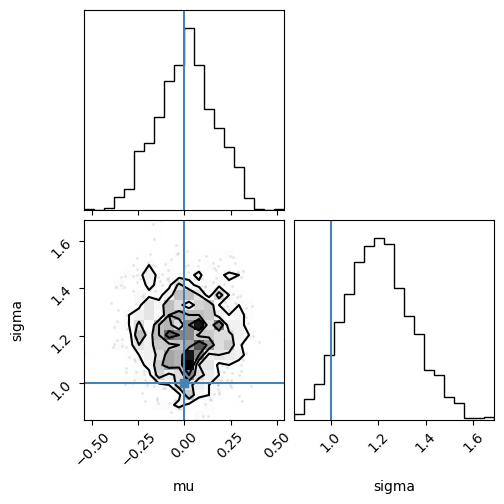

In [14]:
corner.corner(
    np.transpose([mcmc.get_samples()['mu'], mcmc.get_samples()['sigma']]),
    labels = ('mu', 'sigma'),
    truths = (0, 1),
);

## gibbs

In [16]:
def model():
    mu = numpyro.sample('mu', numpyro.distributions.Normal())
    sigma = numpyro.sample('sigma', numpyro.distributions.LogNormal())

    with numpyro.plate('n', obs.size):
        x = numpyro.sample('x', numpyro.distributions.Normal(mu, sigma))
        # x = numpyro.sample('_x', numpyro.distributions.Normal())
        # x = numpyro.deterministic('x', x * sigma + mu)

    ll = jax.vmap(log_likelihood)(obs, x)
    numpyro.factor('factor', ll.sum())

In [19]:
def cumulative_trapezoid(y, x):
    return jnp.cumsum((y[1:] + y[:-1]) * jnp.diff(x) / 2)

def sample(key, obs, mu, sigma):
    x = jnp.linspace(-10, 10, 1_000)
    y = (
        jax.scipy.stats.norm.pdf(obs, x, 1) *
        jax.scipy.stats.norm.pdf(x, mu, sigma)
    )
    cdf = cumulative_trapezoid(y, x)
    cdf = jnp.insert(cdf, 0, 0) / cdf[-1]
    u = jax.random.uniform(key)
    return jnp.interp(u, cdf, x)

def gibbs_fn(rng_key, gibbs_sites, hmc_sites):
    keys = jax.random.split(rng_key, obs.size)
    mu = hmc_sites['mu']
    sigma = hmc_sites['sigma']
    x = jax.vmap(lambda key, obs: sample(key, obs, mu, sigma))(keys, obs)
    return dict(x = x)

hmc_kernel = numpyro.infer.NUTS(model)
kernel = numpyro.infer.HMCGibbs(
    hmc_kernel, gibbs_fn = gibbs_fn, gibbs_sites = ['x'],
)
mcmc = numpyro.infer.MCMC(kernel, num_warmup = 1_000, num_samples = 1_000)
mcmc.run(jax.random.key(2))

sample: 100%|████████| 2000/2000 [00:10<00:00, 196.24it/s, 3 steps of size 5.38e-01. acc. prob=0.92]


In [20]:
mcmc.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
        mu      0.01      0.14      0.01     -0.24      0.22    308.12      1.00
     sigma      1.17      0.16      1.17      0.92      1.41    162.24      1.01
      x[0]     -0.80      0.74     -0.81     -2.18      0.27    796.57      1.00
      x[1]     -0.50      0.78     -0.53     -1.84      0.74    758.75      1.00
      x[2]      1.15      0.76      1.12      0.08      2.53    682.03      1.00
      x[3]      0.63      0.78      0.61     -0.66      1.91    941.03      1.00
      x[4]     -0.46      0.77     -0.43     -1.69      0.76    759.76      1.00
      x[5]      0.21      0.75      0.23     -0.98      1.53    929.48      1.00
      x[6]      0.73      0.78      0.74     -0.43      2.07    953.84      1.00
      x[7]     -0.22      0.74     -0.21     -1.38      0.99    956.95      1.00
      x[8]      0.04      0.74      0.05     -1.23      1.24    979.58      1.00
      x[9]     -1.27      0

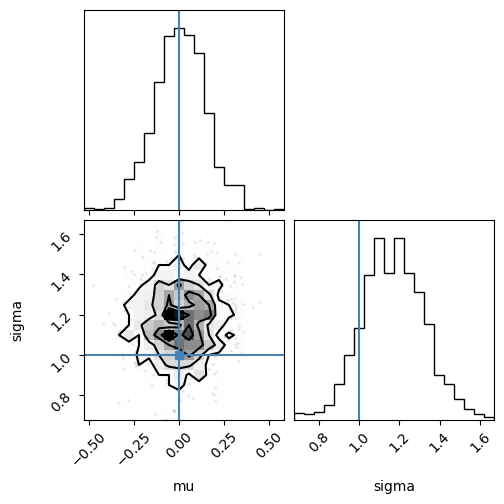

In [21]:
corner.corner(
    np.transpose([mcmc.get_samples()['mu'], mcmc.get_samples()['sigma']]),
    labels = ('mu', 'sigma'),
    truths = (0, 1),
);

In [26]:
inner_kernels = [numpyro.infer.NUTS(model), numpyro.infer.NUTS(model)]
outer_kernel = MultiHMCGibbs(inner_kernels, [['mu', 'sigma'], ['x']])
mcmc = numpyro.infer.MCMC(outer_kernel, num_warmup = 1_000, num_samples = 1_000)
mcmc.run(jax.random.key(2))

sample: 100%|█| 2000/2000 [00:12<00:00, 166.22it/s, 7/7 steps of size 5.69e-01/5.15e-01. acc. prob=0


In [27]:
mcmc.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
        mu      0.01      0.16      0.01     -0.25      0.28    238.32      1.00
     sigma      1.20      0.15      1.19      0.95      1.42    132.22      1.00
      x[0]     -0.79      0.72     -0.81     -2.03      0.34   1486.18      1.00
      x[1]     -0.51      0.75     -0.52     -1.82      0.61   1856.99      1.00
      x[2]      1.16      0.70      1.18      0.00      2.31   1378.56      1.00
      x[3]      0.66      0.77      0.64     -0.53      1.91   1534.25      1.00
      x[4]     -0.43      0.77     -0.45     -1.61      0.92   1394.44      1.00
      x[5]      0.18      0.76      0.20     -1.11      1.36   2173.34      1.00
      x[6]      0.77      0.79      0.74     -0.75      1.88   1263.14      1.00
      x[7]     -0.24      0.74     -0.23     -1.54      0.89   1479.91      1.00
      x[8]      0.02      0.76      0.02     -1.31      1.20   1939.69      1.00
      x[9]     -1.28      0

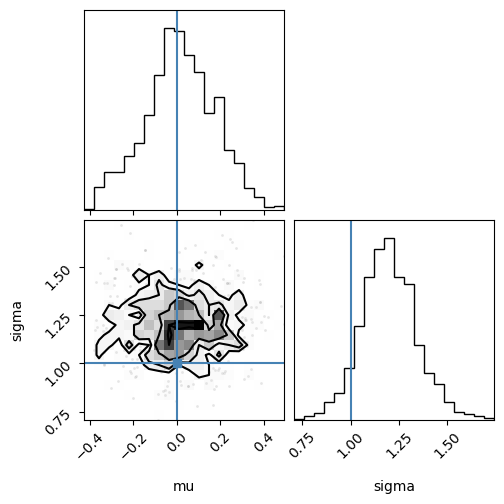

In [28]:
corner.corner(
    np.transpose([mcmc.get_samples()['mu'], mcmc.get_samples()['sigma']]),
    labels = ('mu', 'sigma'),
    truths = (0, 1),
);

In [29]:
def model(obs):
    mu = numpyro.sample('mu', numpyro.distributions.Normal())
    sigma = numpyro.sample('sigma', numpyro.distributions.LogNormal())

    x = jnp.array([
        numpyro.sample(f'x{i}', numpyro.distributions.Normal(mu, sigma))
        for i in range(obs.size)
    ])

    ll = jax.vmap(log_likelihood)(obs, x)
    numpyro.factor('factor', ll.sum())

In [30]:
inner_kernels = [numpyro.infer.NUTS(model)]
sites = [['mu', 'sigma']]
for i in range(obs.size):
    inner_kernels.append(numpyro.infer.NUTS(model))
    sites.append([f'x{i}'])
outer_kernel = MultiHMCGibbs(inner_kernels, sites)
mcmc = numpyro.infer.MCMC(outer_kernel, num_warmup = 1_000, num_samples = 1_000)
mcmc.run(jax.random.key(2), obs)

  0%|                                                                      | 0/2000 [00:00<?, ?it/s]E0301 13:30:24.278957 3245787 slow_operation_alarm.cc:73] 
********************************
[Compiling module jit__body_fn for GPU] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
E0301 13:33:21.766411 3245189 slow_operation_alarm.cc:140] The operation took 4m57.487650137s

********************************
[Compiling module jit__body_fn for GPU] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
  0%|                                                                      | 0/2000 [10:27<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
mcmc.print_summary()

In [ ]:
corner.corner(
    np.transpose([mcmc.get_samples()['mu'], mcmc.get_samples()['sigma']]),
    labels = ('mu', 'sigma'),
    truths = (0, 1),
);

## gibbs test

In [31]:
def model():
     x = numpyro.sample('x', numpyro.distributions.Normal(0.0, 2.0))
     y = numpyro.sample('y', numpyro.distributions.Normal(0.0, 2.0))
     numpyro.sample(
         'obs',
         numpyro.distributions.Normal(x + y, 1.0),
         obs = jnp.array([1.0]),
     )

In [32]:
nuts = numpyro.infer.NUTS(model)
mcmc = numpyro.infer.MCMC(nuts, num_warmup = 1_000, num_samples = 1_000)
mcmc.run(jax.random.key(0))

sample: 100%|████████| 2000/2000 [00:05<00:00, 368.93it/s, 7 steps of size 4.64e-01. acc. prob=0.93]


In [33]:
mcmc.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         x      0.50      1.53      0.51     -2.10      2.95    234.33      1.01
         y      0.34      1.51      0.36     -2.18      2.69    246.15      1.00

Number of divergences: 0


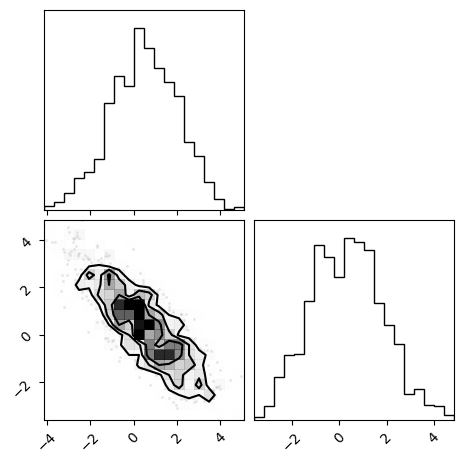

In [34]:
corner.corner(np.transpose(list(mcmc.get_samples().values())));

In [35]:
def gibbs_fn(rng_key, gibbs_sites, hmc_sites):
    y = hmc_sites['y']
    dist = numpyro.distributions.Normal(0.8 * (1 - y), jnp.sqrt(0.8))
    new_x = dist.sample(rng_key)
    return {'x': new_x}

hmc_kernel = numpyro.infer.NUTS(model)
kernel = numpyro.infer.HMCGibbs(
    hmc_kernel, gibbs_fn = gibbs_fn, gibbs_sites = ['x'],
)
mcmc = numpyro.infer.MCMC(kernel, num_warmup = 1_000, num_samples = 1_000)
mcmc.run(jax.random.key(0))

sample: 100%|████████| 2000/2000 [00:03<00:00, 544.66it/s, 3 steps of size 6.51e-01. acc. prob=0.92]


In [36]:
mcmc.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         x      0.44      1.51      0.44     -1.86      3.03    166.31      1.00
         y      0.44      1.48      0.36     -1.89      2.95    124.26      1.00



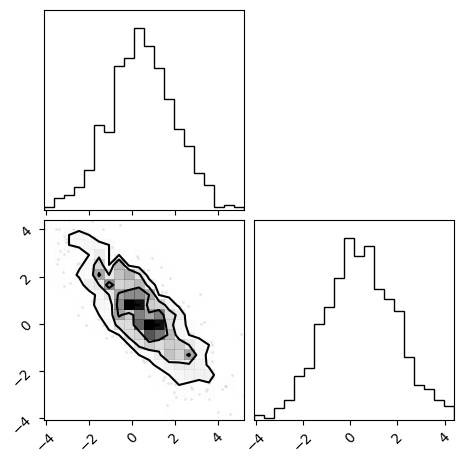

In [37]:
corner.corner(np.transpose(list(mcmc.get_samples().values())));

In [38]:
inner_kernels = [numpyro.infer.NUTS(model), numpyro.infer.NUTS(model)]
outer_kernel = MultiHMCGibbs(inner_kernels, [['y'], ['x']])
mcmc = numpyro.infer.MCMC(outer_kernel, num_warmup = 1_000, num_samples = 1_000)
mcmc.run(jax.random.PRNGKey(0))

sample: 100%|█| 2000/2000 [00:08<00:00, 248.80it/s, 3/3 steps of size 6.19e-01/5.63e-01. acc. prob=0


In [39]:
mcmc.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         x      0.69      1.57      0.71     -2.11      2.84     74.43      1.02
         y      0.12      1.66      0.13     -2.68      2.69     76.91      1.02

Number of divergences: 0


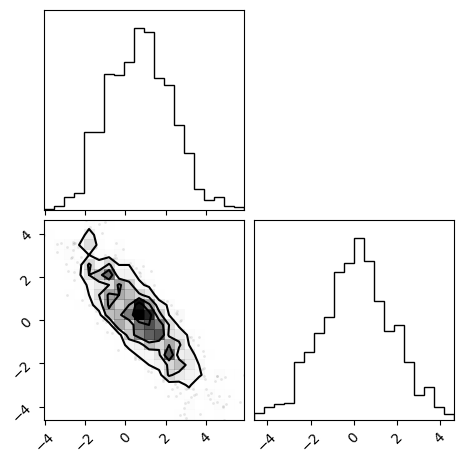

In [40]:
corner.corner(np.transpose(list(mcmc.get_samples().values())));